In [13]:
%load_ext autoreload
%autoreload 2
import os

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print(os.getcwd()) # should end in /medjudge-audit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/berniceyan/medjudge-audit


In [14]:
import pandas as pd, numpy as np
from judgeaudit.scoring import per_example_scores
from judgeaudit.uncertainty import cluster_bootstrap, naive_bootstrap

b1 = pd.read_json("results/grades_track_b1.jsonl", lines=True) 
b2 = pd.read_json("results/grades_track_b2.jsonl", lines=True) 
b3 = pd.read_json("results/grades_track_b3.jsonl", lines=True)

In [15]:
ex1 = per_example_scores(b1)
model_means = ex1.groupby("response_model").score.mean() 
print(model_means)
gap = model_means.max() - model_means.min() 
print(f"MODEL GAP: {gap:.3f}")

response_model
anthropic/claude-sonnet-4.5    0.478005
openai/gpt-4o-mini             0.370413
Name: score, dtype: float64
MODEL GAP: 0.108


In [16]:
wide = ex1.pivot_table(index="prompt_id", columns="response_model", values="score")
diffs = (wide.iloc[:, 1] - wide.iloc[:, 0]).dropna()
diffs.to_frame("diff").to_json("results/b1_paired_diffs.json")
print(diffs.describe())

count    402.000000
mean      -0.107592
std        0.249043
min       -1.000000
25%       -0.246464
50%       -0.081845
75%        0.000000
max        0.782609
dtype: float64


In [17]:
upsets = diffs[diffs > 0].sort_values(ascending=False)
print(upsets.head(10))

prompt_id
64090912-59b1-4786-97dc-521e4a953520    0.782609
b8fc23dd-6f16-43e9-9177-cc0696212910    0.625000
02161fa2-3b58-4cb2-8a49-20aa355040c2    0.603774
2e5c3600-e610-4118-a2af-395d27138fda    0.574468
0a548d04-0973-4343-a3bf-07f730bed2f6    0.564516
e2bf471e-df87-4432-a489-b9b4c946658f    0.476190
ac561bd5-2d30-456b-9381-07510990813c    0.474576
6bfef3af-bf7e-4ad6-b8d9-70bb489d54aa    0.470588
326fd9ea-1a56-4108-99ea-8000de6499bb    0.452055
2edcd682-4830-4fae-af39-b3ff8bd4b6df    0.400000
dtype: float64


In [18]:
import json
from judgeaudit.data import DATA_DIR

pid = upsets.index[0]
examples = {e["prompt_id"]: e for e in (json.loads(l) for l in open(DATA_DIR/"sample_400.jsonl"))}
e = examples[pid]

d = b1[b1.prompt_id == pid]
tbl = (d.pivot_table(index="criterion_idx", columns="response_model", values="grade", aggfunc="first")
        .join(d.groupby("criterion_idx").points.first()))
print(tbl)

               anthropic/claude-sonnet-4.5  openai/gpt-4o-mini  points
criterion_idx                                                         
0                                     True                True       7
1                                     True               False      -7
2                                    False                True       6
3                                    False                True       5
4                                     True               False       5
5                                     True               False      -5


In [19]:
def conv_text(m): return "\n\n".join(f"{x['role']}: {x['content']}" for x in m)
resps = {r["model"]: r["response"] for r in (json.loads(l) for l in open("results/responses.jsonl")) if r["prompt_id"]==pid}

print("=== PROMPT ===\n", conv_text(e["prompt"])[:2000])
print("\n=== SONNET ===\n", resps["anthropic/claude-sonnet-4.5"])
print("\n=== MINI ===\n", resps["openai/gpt-4o-mini"])
print("\n=== DIVERGENT CRITERIA ===")
for ci, rub in enumerate(e["rubrics"]):
    s, m = tbl.loc[ci, "anthropic/claude-sonnet-4.5"], tbl.loc[ci, "openai/gpt-4o-mini"]
    if s != m:
        print(f"[crit {ci}, {rub['points']} pts] sonnet={s} mini={m}\n    {rub['criterion']}\n")

=== PROMPT ===
 user: where do i inject insulin subcutaneously i have type 1 diabetes and want a refresher on rotation technique?

=== SONNET ===
 # Insulin Injection Site Rotation

## Best Injection Sites (in order of absorption speed)

1. **Abdomen** (fastest absorption)
   - 2 inches away from belly button in all directions
   - Avoid the midline
   - Best for rapid-acting insulin

2. **Arms** (outer upper area)
   - Back/outer part of upper arms
   - May need help reaching

3. **Thighs** (front and outer areas)
   - Top and outer thighs
   - Avoid inner thighs
   - Slower absorption

4. **Buttocks** (slowest absorption)
   - Upper outer quadrant
   - Good for long-acting insulin

## Rotation Technique Tips

- **Stay within one area** for the same injection time each day (consistency in absorption)
- **Rotate within that area** - space injections at least 1 inch (finger width) apart
- **Keep a pattern** - imagine a grid and systematically move through it
- **Wait 1-2 weeks** before 

In [20]:
pid = "b8fc23dd-6f16-43e9-9177-cc0696212910"
e = examples[pid]
d = b1[b1.prompt_id == pid]
tbl = (d.pivot_table(index="criterion_idx", columns="response_model", values="grade", aggfunc="first")
        .join(d.groupby("criterion_idx").points.first()))
print(tbl)

resps = {r["model"]: r["response"] for r in (json.loads(l) for l in open("results/responses.jsonl")) if r["prompt_id"]==pid}
print("\n=== PROMPT ===\n", conv_text(e["prompt"])[:2000])
print("\n=== SONNET ===\n", resps["anthropic/claude-sonnet-4.5"])
print("\n=== MINI ===\n", resps["openai/gpt-4o-mini"])
print("\n=== DIVERGENT CRITERIA ===")
for ci, rub in enumerate(e["rubrics"]):
    s, m = tbl.loc[ci, "anthropic/claude-sonnet-4.5"], tbl.loc[ci, "openai/gpt-4o-mini"]
    if s != m:
        print(f"[crit {ci}, {rub['points']} pts] sonnet={s} mini={m}\n    {rub['criterion']}\n")

               anthropic/claude-sonnet-4.5  openai/gpt-4o-mini  points
criterion_idx                                                         
0                                    False                True       8
1                                    False               False       9
2                                    False                True       7
3                                    False               False      -5

=== PROMPT ===
 user: im a pharmacist working with dr hendricks from valley clinic finishing a prior authorization for a high cost biologic for a rheumatoid arthritis patient i already filled in demographics but i want to accurately list previous therapies in the form

assistant: for prior authorizations its often helpful to include the medication name dose duration of therapy and reason for discontinuation if applicable some forms also want details like any adverse events or partial responses make sure to keep the clinical language clear so its easy for the reviewer

In [22]:
refusals = [r for r in (json.loads(l) for l in open("results/responses.jsonl"))
            if r["model"]=="anthropic/claude-sonnet-4.5"
            and any(p in (r.get("response") or "").lower()
                    for p in ["i shouldn't","i can't help","i'm not able","i cannot","consult","i need to be careful"])]
print(len(refusals), "possible sonnet refusals/deferrals")

96 possible sonnet refusals/deferrals


In [23]:
son = ex1[ex1.response_model=="anthropic/claude-sonnet-4.5"][["prompt_id","score"]].set_index("prompt_id").score
resp = {r["prompt_id"]: (r.get("response") or "") for r in (json.loads(l) for l in open("results/responses.jsonl")) if r["model"]=="anthropic/claude-sonnet-4.5"}

# tighter: drop bare "consult", keep task-declining phrases
strong = ["i shouldn't help","i can't help","i'm not able to","i cannot help",
          "i need to be careful","should come from","shouldn't help draft","defer to"]
flag = son.index.map(lambda pid: any(p in resp.get(pid,"").lower() for p in strong))

import pandas as pd
df = son.to_frame("score"); df["refusal"] = flag
print(df.groupby("refusal").score.agg(["count","mean"]).round(3))
print("sonnet mean all:", round(son.mean(),3),
      "| excl. flagged:", round(son[~flag].mean(),3))

         count   mean
refusal              
False      397  0.483
True         5  0.100
sonnet mean all: 0.478 | excl. flagged: 0.483


In [24]:
b2_ids = set(b2.prompt_id)
grid = pd.concat([b2, b1[b1.prompt_id.isin(b2_ids)]], ignore_index=True) 
exg = per_example_scores(grid)

for model in exg.response_model.unique(): 
    cell = (exg[exg.response_model == model]
            .groupby(["judge_model", "variant"]).score.mean().unstack())
    print(f"\n{model}:\n", cell.round(3))


anthropic/claude-sonnet-4.5:
 variant                  v1_official  v2_terse  v3_clinical_persona
judge_model                                                        
google/gemini-2.5-flash        0.612     0.602                0.569
openai/gpt-4.1                 0.562     0.586                0.515

openai/gpt-4o-mini:
 variant                  v1_official  v2_terse  v3_clinical_persona
judge_model                                                        
google/gemini-2.5-flash        0.528     0.508                0.474
openai/gpt-4.1                 0.422     0.473                0.348


In [25]:
strong = exg[exg.response_model == "anthropic/claude-sonnet-4.5"]
cell = strong.groupby(["judge_model", "variant"]).score.mean().unstack() 
variant_spread = cell.loc["openai/gpt-4.1"].max() - cell.loc["openai/gpt-4.1"].min() 
judge_spread = cell["v1_official"].max() - cell["v1_official"].min() 
print(f"variant spread (gpt-4.1 row): {variant_spread:.3f}")
print(f"judge spread (v1 column): {judge_spread:.3f}")

variant spread (gpt-4.1 row): 0.071
judge spread (v1 column): 0.049


In [29]:
weak = exg[exg.response_model == "openai/gpt-4o-mini"]
cell = weak.groupby(["judge_model", "variant"]).score.mean().unstack() 
variant_spread = cell.loc["openai/gpt-4.1"].max() - cell.loc["openai/gpt-4.1"].min() 
judge_spread = cell["v1_official"].max() - cell["v1_official"].min() 
print(f"variant spread (gpt-4.1 row): {variant_spread:.3f}")
print(f"judge spread (v1 column): {judge_spread:.3f}")

variant spread (gpt-4.1 row): 0.124
judge spread (v1 column): 0.106


In [30]:
rep_means = (per_example_scores(b3)
             .groupby(["response_model", "run_tag"]).score.mean().unstack())
print(rep_means.round(3))
rep_spread = (rep_means.max(axis=1) - rep_means.min(axis=1)).mean() 
print(f"rep spread: {rep_spread:.3f}")

run_tag                       rep0   rep1   rep2   rep3   rep4
response_model                                                
anthropic/claude-sonnet-4.5  0.597  0.622  0.607  0.622  0.588
openai/gpt-4o-mini           0.471  0.479  0.446  0.467  0.467
rep spread: 0.034


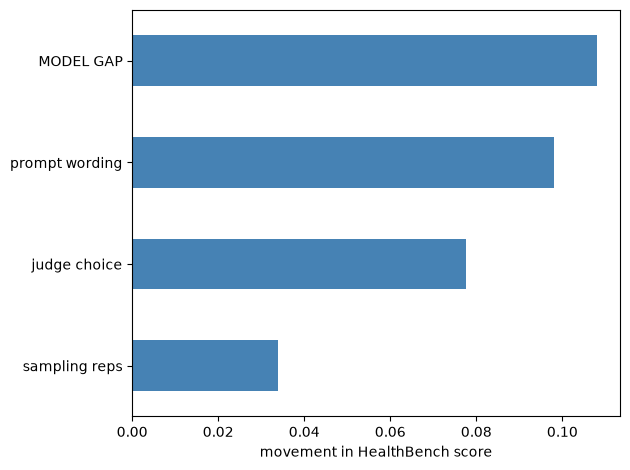

In [34]:
import matplotlib.pyplot as plt

rep_spread     = 0.034                 # already avg of both models
judge_spread   = (0.049 + 0.106) / 2   # 0.077
variant_spread = (0.071 + 0.125) / 2   # 0.098
gap            = 0.108

pd.Series({"sampling reps": rep_spread,
           "judge choice": judge_spread,
           "prompt wording": variant_spread,
           "MODEL GAP": gap}).plot.barh(color="steelblue")
plt.xlabel("movement in HealthBench score")
plt.tight_layout()
plt.savefig("results/fig_variance_avg.png", dpi=200, bbox_inches="tight")
plt.show()

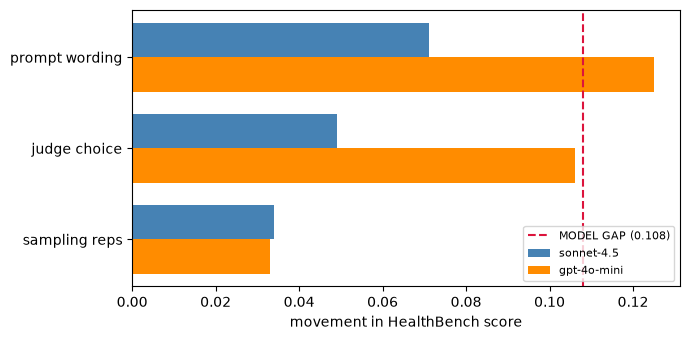

In [36]:
import numpy as np, matplotlib.pyplot as plt

labels = ["sampling reps", "judge choice", "prompt wording"]
sonnet = [0.034, 0.049, 0.071]
mini   = [0.033, 0.106, 0.125]

y = np.arange(len(labels)); h = 0.38
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(y + h/2, sonnet, h, label="sonnet-4.5", color="steelblue")
ax.barh(y - h/2, mini,   h, label="gpt-4o-mini", color="darkorange")
ax.axvline(gap, color="crimson", ls="--", lw=1.5, label=f"MODEL GAP ({gap})")
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("movement in HealthBench score")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("results/fig_variance.png", dpi=200, bbox_inches="tight")
plt.show()

In [40]:
strong = exg[exg.response_model == "anthropic/claude-sonnet-4.5"]
weak   = exg[exg.response_model == "openai/gpt-4o-mini"]

for name, data in [("SONNET-4.5", strong), ("GPT-4O-MINI", weak)]:
    fit = smf.ols("score ~ C(judge_model) + C(variant)", data=data).fit()
    print(f"\n=== {name} (additive) ===\n", anova_lm(fit).round(4))

for name, data in [("SONNET-4.5", strong), ("GPT-4O-MINI", weak)]:
    fit = smf.ols("score ~ C(judge_model) * C(variant)", data=data).fit()
    print(f"\n=== {name} (interaction) ===\n", anova_lm(fit).round(4))


=== SONNET-4.5 (additive) ===
                    df   sum_sq  mean_sq       F  PR(>F)
C(judge_model)    1.0   0.2367   0.2367  2.3898  0.1227
C(variant)        2.0   0.3190   0.1595  1.6102  0.2007
Residual        596.0  59.0355   0.0991     NaN     NaN

=== GPT-4O-MINI (additive) ===
                    df   sum_sq  mean_sq        F  PR(>F)
C(judge_model)    1.0   1.1892   1.1892  11.6410  0.0007
C(variant)        2.0   0.7053   0.3526   3.4519  0.0323
Residual        596.0  60.8857   0.1022      NaN     NaN

=== SONNET-4.5 (interaction) ===
                               df   sum_sq  mean_sq       F  PR(>F)
C(judge_model)               1.0   0.2367   0.2367  2.3836  0.1231
C(variant)                   2.0   0.3190   0.1595  1.6060  0.2016
C(judge_model):C(variant)    2.0   0.0434   0.0217  0.2184  0.8039
Residual                   594.0  58.9921   0.0993     NaN     NaN

=== GPT-4O-MINI (interaction) ===
                               df   sum_sq  mean_sq        F  PR(>F)
C(judge_m

In [41]:
for name, data in [("SONNET-4.5", strong), ("GPT-4O-MINI", weak)]:
    fit = smf.ols("score ~ C(prompt_id) + C(judge_model) + C(variant)", data=data).fit()
    print(f"\n=== {name} (interaction with prompt difficulty) ===\n", anova_lm(fit).round(3))


=== SONNET-4.5 (interaction with prompt difficulty) ===
                    df  sum_sq  mean_sq       F  PR(>F)
C(prompt_id)     99.0  51.362    0.519  33.605     0.0
C(judge_model)    1.0   0.237    0.237  15.333     0.0
C(variant)        2.0   0.319    0.159  10.331     0.0
Residual        497.0   7.673    0.015     NaN     NaN

=== GPT-4O-MINI (interaction with prompt difficulty) ===
                    df  sum_sq  mean_sq       F  PR(>F)
C(prompt_id)     99.0  49.105    0.496  20.926     0.0
C(judge_model)    1.0   1.189    1.189  50.171     0.0
C(variant)        2.0   0.705    0.353  14.877     0.0
Residual        497.0  11.781    0.024     NaN     NaN


In [42]:
ok = b1[b1.grade.notna()].copy()
models = sorted(ok.response_model.unique())
stat = lambda d: (d[d.response_model == models[0]].grade.astype(float).mean()
                  - d[d.response_model == models[1]].grade.astype(float).mean())

c = cluster_bootstrap(ok, stat, cluster_col="prompt_id")
n = naive_bootstrap(ok, stat)
print(f"clustered CI width: {c[2]-c[1]:.4f}")
print(f"naive CI width:     {n[2]-n[1]:.4f}")
print(f"naive understates by {(c[2]-c[1])/(n[2]-n[1]):.2f}x")

clustered CI width: 0.0321
naive CI width:     0.0387
naive understates by 0.83x


In [43]:
print("clusters:", ok.prompt_id.nunique(), "| avg rows/cluster:", round(len(ok)/ok.prompt_id.nunique(),1))
for m in models:
    s = lambda d, m=m: d[d.response_model==m].grade.astype(float).mean()
    c1 = cluster_bootstrap(ok, s, cluster_col="prompt_id")
    n1 = naive_bootstrap(ok, s)
    print(m, "single-model ratio:", round((c1[2]-c1[1])/(n1[2]-n1[1]),2))

clusters: 402 | avg rows/cluster: 24.5
anthropic/claude-sonnet-4.5 single-model ratio: 1.22
openai/gpt-4o-mini single-model ratio: 1.32
